In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

df = pd.read_csv(r"C:\Users\wbdor\Downloads\Car_Crash_Fully_Preprocessed.csv")

X = df.drop("Severity", axis=1)
y = df["Severity"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

knn = KNeighborsClassifier(
    n_neighbors=5,
    weights="distance",
    metric="euclidean",
    n_jobs=-1
)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
y_prob = knn.predict_proba(X_test)[:, 1]

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nROC-AUC:", roc_auc_score(y_test, y_prob))

Confusion Matrix:
 [[30817   606]
 [ 2233   142]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.98      0.96     31423
           1       0.19      0.06      0.09      2375

    accuracy                           0.92     33798
   macro avg       0.56      0.52      0.52     33798
weighted avg       0.88      0.92      0.90     33798


ROC-AUC: 0.6065436011503474


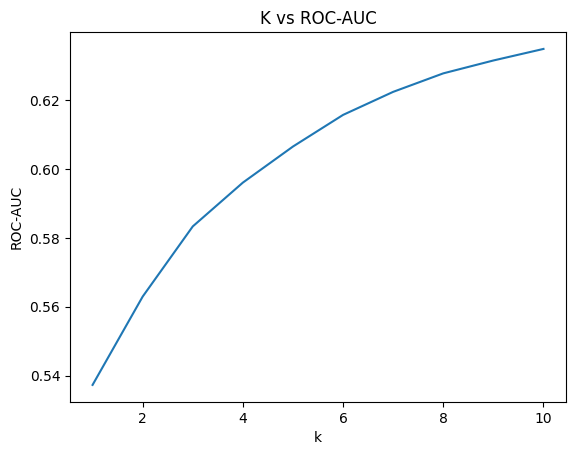

Best k: 10


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score

df = pd.read_csv(r"C:\Users\wbdor\Downloads\Car_Crash_Fully_Preprocessed.csv")

X = df.drop("Severity", axis=1)
y = df["Severity"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

ks = range(1,11)
auc_scores = []

for k in ks:
    m = KNeighborsClassifier(n_neighbors=k, weights="distance", n_jobs=-1)
    m.fit(X_train, y_train)
    y_prob = m.predict_proba(X_test)[:,1]
    auc_scores.append(roc_auc_score(y_test, y_prob))

plt.plot(ks, auc_scores)
plt.xlabel("k")
plt.ylabel("ROC-AUC")
plt.title("K vs ROC-AUC")
plt.show()

print("Best k:", ks[np.argmax(auc_scores)])

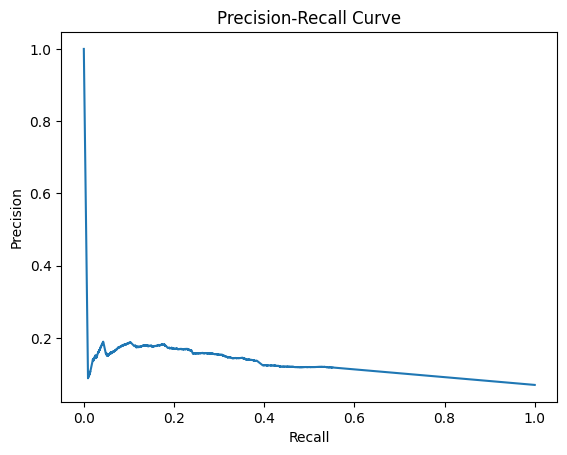

Average Precision: 0.11375392695618027


In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

y_prob = model.predict_proba(X_test)[:,1]

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

print("Average Precision:", ap)

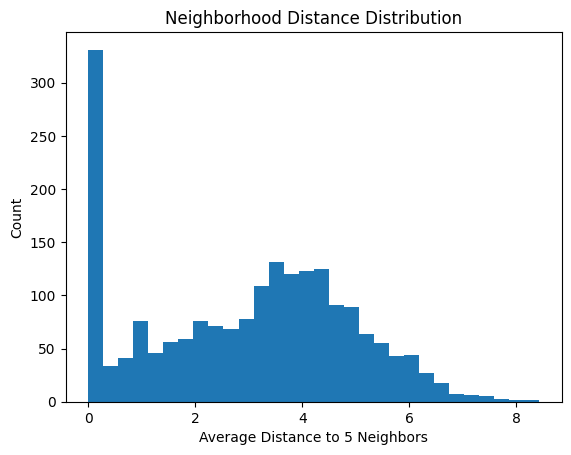

In [15]:
import numpy as np

distances, _ = model.kneighbors(X_test[:2000])
mean_dist = distances.mean(axis=1)

plt.hist(mean_dist, bins=30)
plt.xlabel("Average Distance to 5 Neighbors")
plt.ylabel("Count")
plt.title("Neighborhood Distance Distribution")
plt.show()

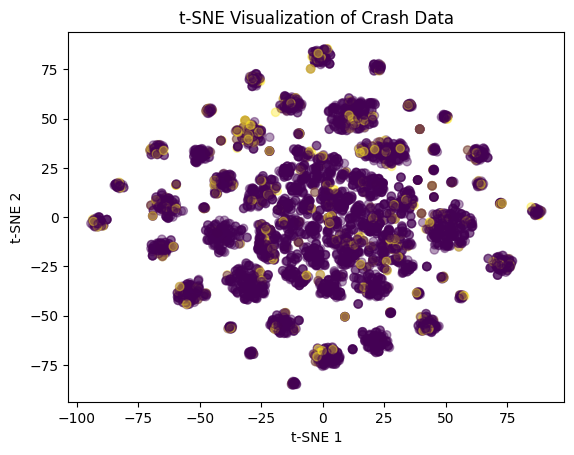

In [16]:
from sklearn.manifold import TSNE

sample = X_train[:5000]
labels = y_train[:5000]

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(sample)

plt.scatter(X_tsne[:,0], X_tsne[:,1], c=labels, alpha=0.4)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE Visualization of Crash Data")
plt.show()

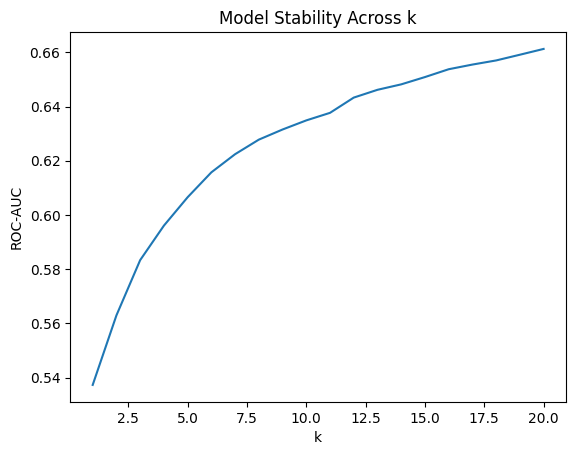

In [17]:
ks = range(1,21)
auc_scores = []

for k in ks:
    m = KNeighborsClassifier(n_neighbors=k, weights="distance", n_jobs=-1)
    m.fit(X_train, y_train)
    y_prob_k = m.predict_proba(X_test)[:,1]
    auc_scores.append(roc_auc_score(y_test, y_prob_k))

plt.plot(ks, auc_scores)
plt.xlabel("k")
plt.ylabel("ROC-AUC")
plt.title("Model Stability Across k")
plt.show()

In [18]:
from sklearn.linear_model import LogisticRegression
from statsmodels.stats.contingency_tables import mcnemar
from sklearn.metrics import confusion_matrix

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

knn = KNeighborsClassifier(n_neighbors=5, weights="distance")
lr = LogisticRegression(max_iter=1000)

knn.fit(X_train, y_train)
lr.fit(X_train, y_train)

pred_knn = knn.predict(X_test)
pred_lr = lr.predict(X_test)

table = confusion_matrix(pred_knn, pred_lr)
result = mcnemar(table)

print("McNemar p-value:", result.pvalue)

McNemar p-value: 2.0854866237607577e-184


P-value, significant